# Quantifying water released from a glacier in Southern Greenland

Three seismometers were placed near the glacier Eqalorutsit Kangilliit Sermiat. Water melt/discharge from this glacier causes a noticeable signal in the seismic tremor. The goal of this project is to quantify the amount of water released from this glacier using tremor data.


We analyze time-series tremor data (which should be in the folder `./QJT_DATA/`) spanning about 2 years from 3 seismometers measuring 3D tremor data (though we focus primarily on the Z axis)

In [11]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib
import datetime
import obspy
from obspy import UTCDateTime
from obspy.clients.filesystem.sds import Client
from multiprocessing import Pool
import statsmodels.api as sm
import statsmodels.formula.api as smf

Below is a quick preview of what the data looks like visualized.

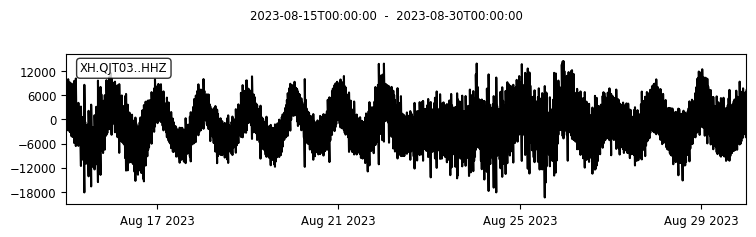

In [12]:
# Read data
client = Client('./QJT_data/')

t_start = UTCDateTime('2023-08-15')
t_end = UTCDateTime('2023-08-30')
# only read 1 station and 1 channel for now
st_read = client.get_waveforms('XH', 'QJT03', '', 'HHZ', t_start, t_end)
st_read.merge()
initial_plot = st_read.plot()

The first step in processing the tremor is separating the signal from the noise. We want to see what tremor frequencies are most associated with glacial discharge. One strategy we can use is comparing cold day vs. hot day discharge patterns. The thinking is that on hot days, there should be significantly more melt and discharge, and so by comparing the two we can see which frequency ranges lead to the biggest differences. We can create power spectral density plots to visualize these hot vs. cold patterns.

We start by calculating the data needed to make these plots. We save the data to a file called `psd.npz`. Note that this process takes a while: please use the already generated `psd.npz`. The below cell has the code to calculate this data, but by default, it is not set to run unless you change the variable `REPROCESS_DATA` to be `True`. Do not change this variable unless you need to reprocess the data.

In [13]:
REPROCESS_DATA = False

if REPROCESS_DATA:
    # Read data
    client = Client('QJT_data')

    t_start = UTCDateTime('2023-09-01')
    t_end = t_start + 24*3600
    # only read 1 station and 1 channel for now

    PxxArr = np.ones(6001)
    freqsArr = np.ones(6001)

    while t_start < UTCDateTime('2024-07-11'):
        print(t_start, t_end)
        stream = client.get_waveforms('XH', 'QJT03', '', 'HHZ', t_start, t_end)
        stream.merge()
        tr = stream.select(component='Z')[0]
        data = tr.data
        fs = tr.stats.sampling_rate #sampling rate
        NFFT = int(fs*60)
        Pxx, freqs = plt.psd(x=data, NFFT=NFFT, Fs=fs, detrend = 'linear') # run this again w/ detrend, fixes linear drift
        t_start = t_end
        t_end = t_end + 24*3600
        PxxArr = np.vstack((PxxArr, Pxx))
        freqsArr = np.vstack((freqsArr, freqs))

    # problematic days in 2023: 08/01, 08/02, 08/30
    # and in 2024: 07/11
    # last day 2024-07-27

    np.savez_compressed('psd.npz', freqsArr = freqsArr, PxxArr = PxxArr)


We now process the power spectral density data to create the plots that we want. Note that the files `psd.npz` and `meteo_bay_2022-24.csv` need to be in the same folder as this notebook.


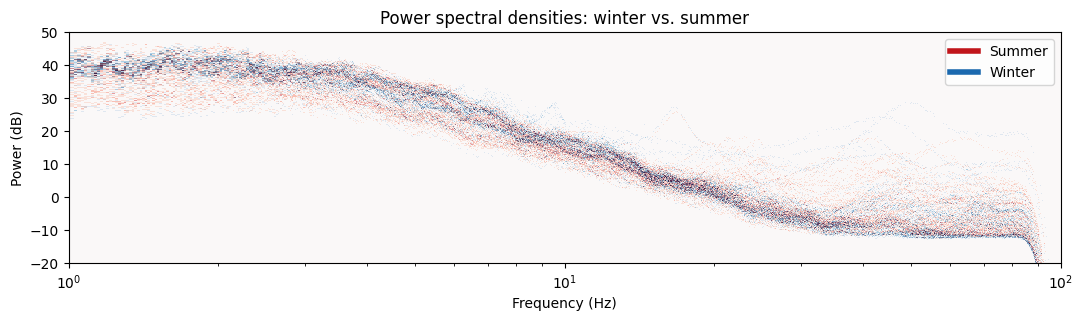

In [14]:
# Code to process the power spectral density data. Mainly various numpy and panda manipulations.
data = np.load('psd.npz')
freqsArr = data['freqsArr']
PxxArr = data['PxxArr']

melt = np.vstack((PxxArr[1:100], PxxArr[-67:]))
weather = pd.read_csv("meteo_bay_2022-24.csv")
weather["Year"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[0]))
weather["Month"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[1]))
weather["Day"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[2]))
weather = weather[((weather["Year"] == 2023) & (weather["Month"] > 8)) | 
                  ((weather["Year"] == 2024) & (weather["Month"] < 7)) |
                  ((weather["Year"] == 2024) & (weather["Month"] == 7) & (weather["Day"] < 11))]
temps = weather.groupby(["Year", "Month", "Day"])["Temp [C]"].mean().to_numpy()
temps = np.hstack((temps[1:100], temps[-67:]))

# We split the days into hot and cold days.
warm = melt[temps >= np.median(temps)]
cool = melt[temps < np.median(temps)]
rows_warm = 10*np.log10(warm).T
rows_cool = 10*np.log10(cool).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_warm = np.ones(precision)
histograms_cool = np.ones(precision)

for row in rows_warm:
    histograms_warm = np.vstack((histograms_warm, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_warm = histograms_warm / d_amplitude / len(rows_warm)

for row in rows_cool:
    histograms_cool = np.vstack((histograms_cool, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_cool = histograms_cool / d_amplitude / len(rows_cool)

# Now we make the power spectral density graphs.
plt.figure(figsize=(2*6.4,3))
im1 = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_warm.T, vmin = 0, vmax = 0.005, cmap = "Reds") 
im2 = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_cool.T, vmin = 0, vmax = 0.005, cmap = "Blues", alpha = 0.575)
plt.xscale('log')
plt.xlim(1, 100)
plt.title("Power spectral densities: winter vs. summer")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")

custom_lines = [Line2D([0], [0], color=matplotlib.colormaps['Reds'](200), lw=4),
                Line2D([0], [0], color=matplotlib.colormaps['Blues'](200), lw=4)]
plt.legend(custom_lines, ['Summer', 'Winter'], loc = 'upper right')

The plots above show the most pronounced differences in the 1-10 Hz frequency ranges. We can guess that tremor in this frequency range is indicative of glacial discharge. 

For this next part, we need data processed by `process_tremor.py` and stored in `./results_all_z_new/`. The first thing we do here is calculate the strength of the tremor in our frequency range of interest (**and smaller frequency ranges within that**) across all three stations.

We can plot the strength of vibrations in this range to get a relative measure of the glacial discharge. We do so for a few months of the year.

/var/folders/5l/029x820d3hjgnct_bv_xsyzr0000gn/T/ipykernel_37779/765231853.py:30: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_ght = pd.concat(df_list, axis='columns')


(np.float64(19844.0), np.float64(19936.0))

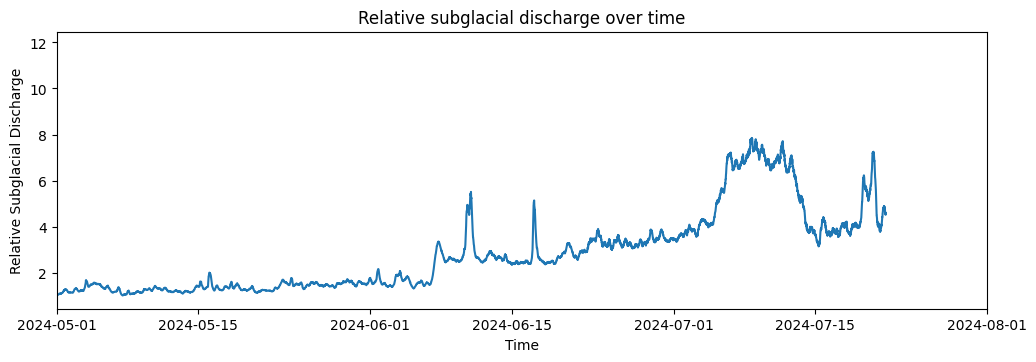

In [15]:
# Load in data to find approximate tremor strength in the frequency band of interest (and smaller frequency bands within this)

times = np.load("results_all_z_new/0.npz", allow_pickle = True)["times"]
GHTs = np.load("results_all_z_new/0.npz", allow_pickle = True)["GHT"]
for i in range(1, 354):
    times = np.hstack((times, np.load("results_all_z_new/" + str(i) + ".npz", allow_pickle = True)["times"]))
    GHTs = np.dstack((GHTs, np.load("results_all_z_new/" + str(i) + ".npz", allow_pickle = True)["GHT"]))
    # print(str(i), end = '\r')

times = times[0]
np.shape(GHTs)
np.shape(times)
# GHTs
freqbounds = [(1, 4), (4, 7), (7, 10)]
stations = ['QJT01', 'QJT02', 'QJT03']

# Calculate mean GHT between stations
df_list = []

# Put GHT data into DataFrames
for idx1, freqbound in enumerate(freqbounds):
    for idx2, station in enumerate(stations):
      t = times.copy()
      GHT = GHTs[idx1, idx2, :].copy()
      df = pd.DataFrame(data=GHT, index=t, columns = [(freqbound, station)])
      df_alt = df.iloc[:-2] 
      df_list.append(df)

# Merge the three DataFrames into a single one
df_ght = pd.concat(df_list, axis='columns')

# Normalization
df_ght = df_ght.divide(df_ght.median(skipna=True))

# Rolling averaging for each station
df_ght = df_ght.rolling('6h', center=True).median()

df_ght.iloc[:, [0, 3, 6]] = df_ght.iloc[:, [0, 3, 6]] / df_ght.iloc[:, [0, 3, 6]].sum().sum()

df_ght.iloc[:, [1, 4, 7]] = df_ght.iloc[:, [1, 4, 7]] / df_ght.iloc[:, [1, 4, 7]].sum().sum()

df_ght.iloc[:, [2, 5, 8]] = df_ght.iloc[:, [2, 5, 8]] / df_ght.iloc[:, [2, 5, 8]].sum().sum()

# Mean between stations
df_ght['mean'] = df_ght.mean(axis='columns')

# Setting GHT relative to minimum power
df_ght = df_ght / np.nanmin(df_ght['mean'])

# Standard Deviation
df_ght['std'] = df_ght[:-1].std(axis='columns')

df_ght['mean14'] = df_ght.iloc[:, 0:3].mean(axis='columns')
df_ght['std14'] = df_ght.iloc[:, 0:3].std(axis='columns')
df_ght['mean47'] = df_ght.iloc[:, 3:6].mean(axis='columns')
df_ght['std47'] = df_ght.iloc[:, 3:6].std(axis='columns')
df_ght['mean710'] = df_ght.iloc[:, 6:9].mean(axis='columns')
df_ght['std710'] = df_ght.iloc[:, 6:9].std(axis='columns')

fig = plt.figure(figsize=(12,3.6))
plt.plot(df_ght.index, np.sqrt(df_ght['mean']))
plt.ylabel('Relative Subglacial Discharge')
plt.xlabel('Time')
plt.title("Relative subglacial discharge over time")
plt.xlim(np.datetime64('2024-05-01'), np.datetime64('2024-08-01'))

Observe that there is a large bump in glacial discharge from about the 3rd of July to the 15th. Around this time, a subglacial lake experienced an outburst event where a lot of water was released.

We have a way to directly estimate the volume of water released from that lake outburst event, and since the bulk of the water being released from the entire glacier is from that event, it will give us a good approximation of the water released from the entire glacier. We specifically know how the height of the lake changes over time (in the file `GPS_box_moraine_splinesmooth_10min.csv`) and the area of the lake, so we can use that to calculate the amount of water released.

In [16]:
df_gps = pd.read_csv('GPS_box_moraine_splinesmooth_10min.csv', index_col=0)
df_gps['time'] = pd.to_datetime(df_gps['date']).dt.tz_localize(None)
df_gps.drop(['date'], axis='columns', inplace=True)
df_gps.set_index('time', inplace=True)

get_day = np.vectorize(lambda x: eval(x.strftime('%d + (int(\'%H\')/24) + (int(\'%M\')/1440) + (%S.%f/86400)')))



x = get_day(df_gps.index.to_pydatetime()).tolist()
y = df_gps['height_spline'].to_list()

pairs = sorted(list(zip(x,y)), key = lambda pair: pair[0])
x = [pair[0] for pair in pairs]
y = [- 5000000 * pair[1] / 3 for pair in pairs]

time_int = 300 / 60 / 60 / 24 # 300 seconds

xs_finals = []
# 12th, 16:21:55
start = 12 + 16/24 + 25/(24*60) 
curr = start
while curr < 16:
    xs_finals.append(curr)
    curr += time_int

volume_time_curve = scipy.interpolate.CubicSpline(x, y)
ys_finals = volume_time_curve.derivative()(xs_finals)

pairs = np.array(list(zip(xs_finals, ys_finals)))
xs_finals  = pairs[:,0]

xs_finals = [datetime.datetime(year = 2024, 
                        month = 7, 
                        day = int(x // 1), 
                        hour = int((x % 1 * 24) // 1),
                        minute = round(((x % 1 * 24) % 1 * 60)) % 60,
                        second = 0) for x in xs_finals]

ys_finals = pairs[:,1]
ys_finals /= 86400 # scales the discharge to m^3s^(-1)

discharge = dict(zip(xs_finals, ys_finals))

Now that we know the discharge of the glacier from that event, we can find the mathematical relationship between glacial tremor and glacial discharge and extrapolate the glacial discharge for the rest of the year.

In [17]:
# Find parts of year that have both tremor data and discharge data so that we can fit a model
trimmed_df_ght = df_ght[(df_ght.index < datetime.datetime(2024, 7, 16)) & (df_ght.index > datetime.datetime(2024, 7, 12, 16, 20))]
trimmed_df_ght["discharge"] = trimmed_df_ght.index.to_series().apply(lambda x: discharge[pd.to_datetime(x).to_pydatetime()])
# ref_power = trimmed_df_ght.iloc[-77,:]["mean"]
trimmed_df_ght

# Filter the tremor and discharge to smooth it out and make modeling and possible visualization easier
sos = scipy.signal.butter(4, 1/(86400), 'lp', fs = 1/600, output = 'sos')
filtered_tremor = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean"])
filtered_tremor14 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean14"])
filtered_tremor47 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean47"])
filtered_tremor710 = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["mean710"])
filtered_discharge = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["discharge"])

filtered_discharge = scipy.signal.sosfiltfilt(sos, trimmed_df_ght["discharge"])

# After the outburst event, the lake's water started refilling, meaning the volume increased and the discharge is "negative".
# We filter out rows with "negative" discharge.
more_trimmed_df_ght = trimmed_df_ght[trimmed_df_ght["discharge"] > 0]

It's worth taking a minute to discuss the mathematical model we're fitting. The literature indicates that glacial discharge and tremor follow some kind of power law:

$$Q=aP^b$$

where $Q$ is discharge, $P$ is tremor, and $a$ and $b$ constants that define the relationship between $Q$ and $P$. We find the power law (or the $b$) that relate the two variables first, and then we find the coefficient $a$ that correctly scales them.

/var/folders/5l/029x820d3hjgnct_bv_xsyzr0000gn/T/ipykernel_37779/3247898684.py:12: RuntimeWarning: invalid value encountered in log
  ax.scatter(np.log(filtered_tremor), np.log(filtered_discharge))


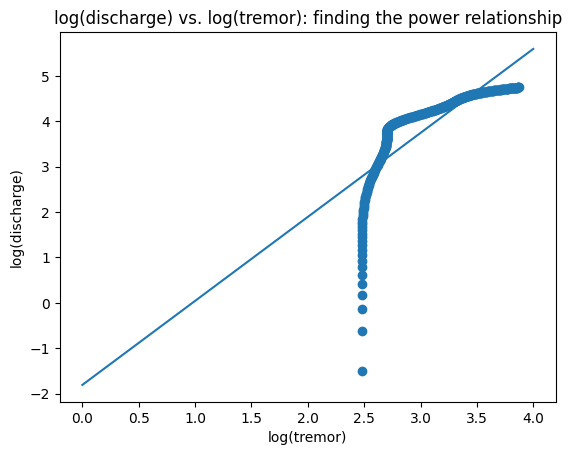

In [18]:
# Finding a power law (or the constant "a" from above)
model_find_slope = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope14 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean14"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope47 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean47"]), np.log(more_trimmed_df_ght["discharge"]))
model_find_slope710 = scipy.stats.linregress(np.log(more_trimmed_df_ght["mean710"]), np.log(more_trimmed_df_ght["discharge"]))
power = model_find_slope.slope
power14 = model_find_slope14.slope
power47 = model_find_slope47.slope
power710 = model_find_slope710.slope
fig, ax = plt.subplots()
ax.scatter(np.log(filtered_tremor), np.log(filtered_discharge))
ax.set_xlabel("log(tremor)")
ax.set_ylabel("log(discharge)")
ax.set_title("log(discharge) vs. log(tremor): finding the power relationship")
plt.plot(range(5), model_find_slope.intercept + model_find_slope.slope * range(5))

Above is a plot that shows how the slope of the line relating the logarithm of the discharge and the logarithm of the tremor gives us the power ($a$) that relates the discharge and tremor.

Below we fit the coefficient ($b$) to scale the relationship correctly.

In [19]:
# Finding the coefficient "b" and fitting a model one way. 
# It's unclear to me currently why we use trimmed_df_ght for this part and not more_trimmed_df_ght.
# TODO (for the next person): figure this out.
ols_df = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean"], power)], axis = 1)
results = smf.ols('discharge ~ mean - 1', ols_df).fit()
ols_df14 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean14"], power14)], axis = 1)
results14 = smf.ols('discharge ~ mean14 - 1', ols_df14).fit()
ols_df47 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean47"], power47)], axis = 1)
results47 = smf.ols('discharge ~ mean47 - 1', ols_df47).fit()
ols_df710 = pd.concat([trimmed_df_ght["discharge"], np.power(trimmed_df_ght["mean710"], power710)], axis = 1)
results710 = smf.ols('discharge ~ mean710 - 1', ols_df710).fit()

We've fit a power law now and have a model, but we want to smoothen out our estimates first (as there are some sudden spikes in tremor caused by unrelated phenomena).

In [20]:
slope = results.params.iloc[0]
moe = results.bse.iloc[0] * 1.96

slope14 = results14.params.iloc[0]
slope47 = results47.params.iloc[0]
slope710 = results710.params.iloc[0]

before = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean"]
during = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean"], 361)
after = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean"]

before14 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean14"]
during14 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean14"], 361)
after14 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean14"]

before47 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean47"]
during47 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean47"], 361)
after47 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean47"]

before710 = df_ght.loc[(df_ght.index <= '2023-10-29 00:00:00'), "mean710"]
during710 = scipy.signal.medfilt(df_ght.loc[(df_ght.index > '2023-10-29 00:00:00') & (df_ght.index < '2024-01-01 00:00:00'), "mean710"], 361)
after710 = df_ght.loc[(df_ght.index >= '2024-01-01 00:00:00'), "mean710"]

smoothened = np.concatenate([before, during, after])
smoothened14 = np.concatenate([before14, during14, after14])
smoothened47 = np.concatenate([before47, during47, after47])
smoothened710 = np.concatenate([before710, during710, after710])

With our model more smoothed out, we can finally estimate and plot the absolute amount of water discharged (in $m^3 s^{-1}$).

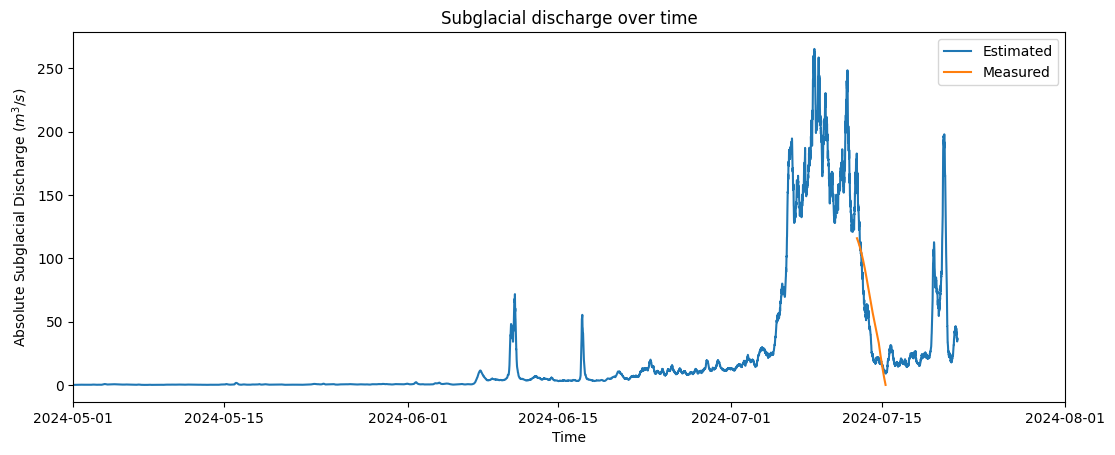

In [21]:
fig = plt.figure(figsize=(2*6.4,4.8))
plt.plot(df_ght.index, slope * np.power(smoothened, power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel(r'Absolute Subglacial Discharge ($m^3/s$)')
plt.xlabel('Time')
plt.xlim(np.datetime64('2024-05-01'), np.datetime64('2024-08-01'))
plt.title("Subglacial discharge over time")
plt.legend(["Estimated", "Measured"])


And in the plot below, we plot our estimate along with a margin of error. We also plot the discharge estimates obtained from smaller frequency ranges within the one we identified.

(np.float64(19844.0), np.float64(19936.0))

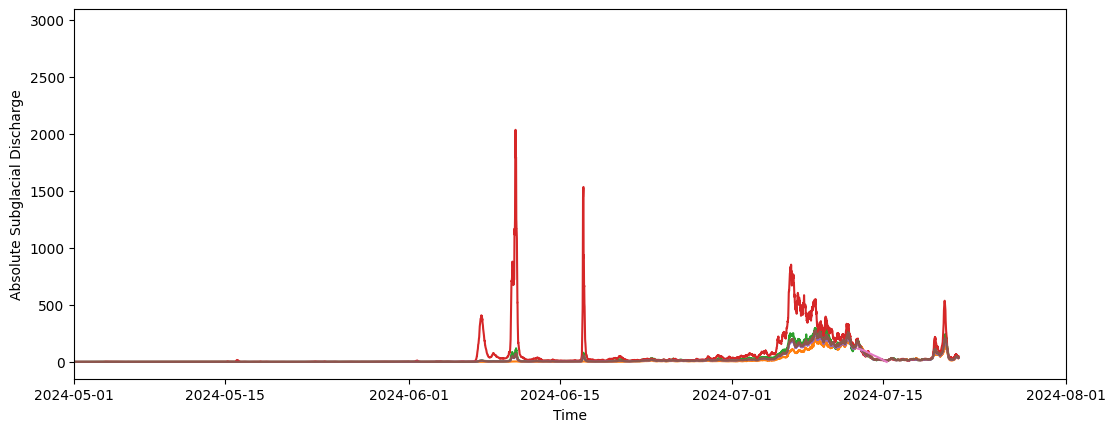

In [ ]:
fig = plt.figure(figsize=(2*6.4,4.8))

plt.plot(df_ght.index, slope * np.power(smoothened, power))
plt.plot(df_ght.index, slope14 * np.power(smoothened14, power14))
plt.plot(df_ght.index, slope47 * np.power(smoothened47, power47))
plt.plot(df_ght.index, slope710 * np.power(smoothened710, power710))
plt.plot(df_ght.index, (slope - moe) * np.power(smoothened, power))
plt.plot(df_ght.index, (slope + moe) * np.power(smoothened, power))
plt.plot(more_trimmed_df_ght.index, more_trimmed_df_ght["discharge"])
plt.ylabel('Absolute Subglacial Discharge')
plt.xlabel('Time')
plt.title("Subglacial discharge over time")
plt.xlim(np.datetime64('2024-05-01'), np.datetime64('2024-08-01'))
# TODO: add a legend explaining what the differnet lines mean.

Some takeaways:
- We have a measurement of the glacial discharge.
- Not a perfect estimate: can the frequency range be more accurate? Does the same relationship hold throughout the year?
- Making it more clear what our margin of error is can help.
- Important in monitoring effects of climate change: getting good measurements of glacial melt and examining its relationship with other variables (e.g. temperature) could be informative.